# Model Evaluation
### Chest X-Ray Classification: Normal vs Pneumonia vs COVID-19
This notebook evaluates both the baseline CNN and ResNet50 models using confusion matrix, precision, recall and F1-score per class.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pneumonia-detection/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

In [3]:
# Device setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Dataset paths
data_dir = Path('../data/Dataset')
train_dir = data_dir / 'Train_Validation'
test_dir = data_dir / 'Test'
classes = ['COVID', 'Normal', 'Pneumonia']

Using device: mps


In [4]:
# Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Dataset class
class XRayDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        for label, cls in enumerate(classes):
            class_dir = self.data_dir / cls
            for img_path in class_dir.glob('*'):
                self.image_paths.append(img_path)
                self.labels.append(label)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        label = self.labels[index]
        return image, label

# Create test dataset and loader
test_dataset = XRayDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 341


In [5]:
# Load Baseline CNN
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 3)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Load baseline model weights
baseline_model = BaseCNN().to(device)
baseline_model.load_state_dict(torch.load('../models/baseline_cnn.pth', map_location=device))
baseline_model.eval()
print("Baseline CNN loaded")

# Load ResNet50 model
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 3)
resnet_model.load_state_dict(torch.load('../models/resnet50.pth', map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()
print("ResNet50 loaded")

Baseline CNN loaded


/var/folders/md/z42njwbn00bbw9kn9gqmhyx40000gn/T/ipykernel_39719/1889977641.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_model.load_state_dict(torch.load('.

ResNet50 loaded


In [6]:
def get_predictions(model, loader):
    """Get all predictions and true labels for a dataset"""
    all_predictions = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_predictions
    

In [7]:
# Get predictions for both models on test set
print("Evaluating Baseline CNN...")
baseline_labels, baseline_preds = get_predictions(baseline_model, test_loader)

print("Evaluating ResNet50...")
resnet_labels, resnet_preds = get_predictions(resnet_model, test_loader)

print("Evaluation complete")

Evaluating Baseline CNN...
Evaluating ResNet50...
Evaluation complete


In [8]:
# Classification report - precision, recall, F1 per class
print("=" * 50)
print("BASELINE CNN - Classification Report")
print("=" * 50)
print(classification_report(baseline_labels, baseline_preds, target_names=classes))

print("=" * 50)
print("RESNET50 - Classification Report")
print("=" * 50)
print(classification_report(resnet_labels, resnet_preds, target_names=classes))

BASELINE CNN - Classification Report
              precision    recall  f1-score   support

       COVID       0.71      0.91      0.80       116
      Normal       0.95      0.64      0.77       112
   Pneumonia       0.62      0.64      0.63       113

    accuracy                           0.73       341
   macro avg       0.76      0.73      0.73       341
weighted avg       0.76      0.73      0.73       341

RESNET50 - Classification Report
              precision    recall  f1-score   support

       COVID       0.70      0.85      0.77       116
      Normal       0.91      0.90      0.91       112
   Pneumonia       0.74      0.58      0.65       113

    accuracy                           0.78       341
   macro avg       0.78      0.78      0.78       341
weighted avg       0.78      0.78      0.78       341



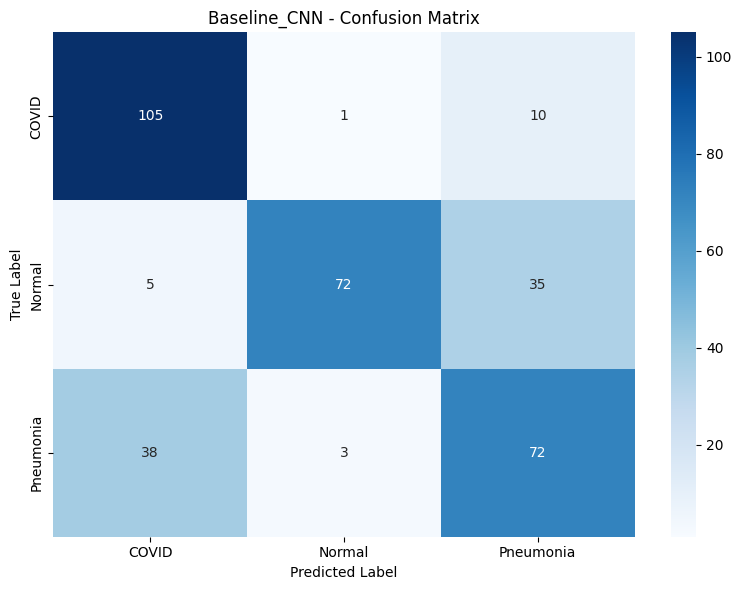

Saved to results folder


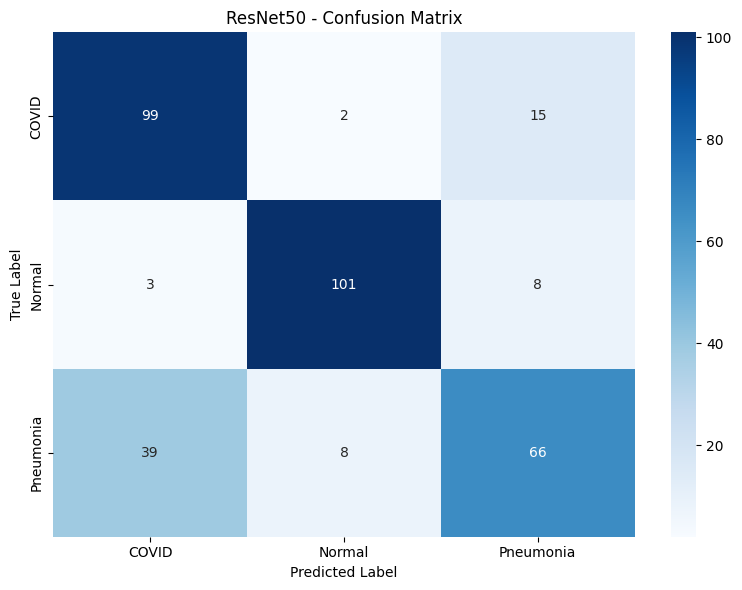

Saved to results folder


In [9]:
def plot_confusion_matrix(labels, predictions, model_name):
    """Plot confusion matrix for a model"""
    cm = confusion_matrix(labels, predictions)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'../results/{model_name}_confusion_matrix.png')
    plt.show()
    print(f"Saved to results folder")

# Plot for both models
plot_confusion_matrix(baseline_labels, baseline_preds, 'Baseline_CNN')
plot_confusion_matrix(resnet_labels, resnet_preds, 'ResNet50')